In [4]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import open3d as o3d
from segment_anything import sam_model_registry, SamPredictor


# Paths
data_path = "../data/Replica/room_0/imap/00/"
rgb_path = os.path.join(data_path, "rgb/rgb_0.png")
depth_path = os.path.join(data_path, "depth/depth_0.png")

# Load
rgb = plt.imread(rgb_path)
depth_raw = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)

if depth_raw is None:
    print(f"❌ Error: Could not load depth map at {depth_path}")
else:
    # --- THE FIX ---
    # Divide by 1000.0 because raw 5007 / 1000 = 5.007 meters (Correct for iMAP)
    depth_meters = depth_raw.astype(np.float32) / 1000.0

# --- CONFIGURATION ---
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
CHECKPOINT = "../checkpoints/weights/sam_vit_h_4b8939.pth"
MODEL_TYPE = "vit_h"

# Replica Room_0 Intrinsics (from vMAP/iMAP configs)
# These are the "Lens Parameters" needed to un-distort pixels into 3D
INTRINSICS = {
    "fx": 600.0, "fy": 600.0,
    "cx": 599.5, "cy": 339.5
}

# 1. Initialize SAM on Mac GPU
sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT).to(DEVICE)
predictor = SamPredictor(sam)

def get_3d_cloud(rgb, depth_meters, mask):
    """ Back-projects masked pixels into (X, Y, Z) space. """
    h, w = depth_meters.shape
    v, u = np.indices((h, w)) # Create pixel grid
    
    # Filter only the object pixels
    z = depth_meters[mask]
    u = u[mask]
    v = v[mask]
    
    # Pinhole Camera Math: $X = \frac{(u - c_x)Z}{f_x}$
    x = (u - INTRINSICS['cx']) * z / INTRINSICS['fx']
    y = (v - INTRINSICS['cy']) * z / INTRINSICS['fy']
    
    points = np.stack([x, y, z], axis=1)
    
    # Create Open3D Point Cloud
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    
    # Optional: Get colors for the points
    colors = rgb[mask] / 255.0 if rgb.max() > 1.0 else rgb[mask]
    pcd.colors = o3d.utility.Vector3dVector(colors)
    
    return pcd

# --- EXECUTION ---
# Let's target the chair. In frame_0, a point on the chair is roughly (x=400, y=500)
input_point = np.array([[400, 500]]) 
input_label = np.array([1]) # 1 = foreground

predictor.set_image(rgb)
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

# Use the mask with the highest score
best_mask = masks[np.argmax(scores)]

# Convert to 3D
object_pcd = get_3d_cloud(rgb, depth_meters, best_mask)

# Clean noise (essential for robotics data)
object_pcd, _ = object_pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)

# Save it to check in MeshLab or visualize here
o3d.io.write_point_cloud("assets/segmented_chair.pcd", object_pcd)
print(f"✅ Success! Saved {len(object_pcd.points)} points to assets/segmented_chair.pcd")

[Open3D WARNING] Write PCD failed: unable to open file.
✅ Success! Saved 9126 points to assets/segmented_chair.pcd


In [ ]:
# See the point cloud in 3D
o3d.visualization.draw_geometries([object_pcd], 
                                  window_name="SAM Segmented Object",
                                  width=800, height=600)

In [ ]:
# Check dimensions (for robotics, we care about real-world scale!)
bbox = object_pcd.get_axis_aligned_bounding_box()
extent = bbox.get_extent()
print(f"Object Dimensions (meters): Width={extent[0]:.2f}, Height={extent[1]:.2f}, Depth={extent[2]:.2f}")

Object Dimensions (meters): Width=0.48, Height=0.22, Depth=0.37


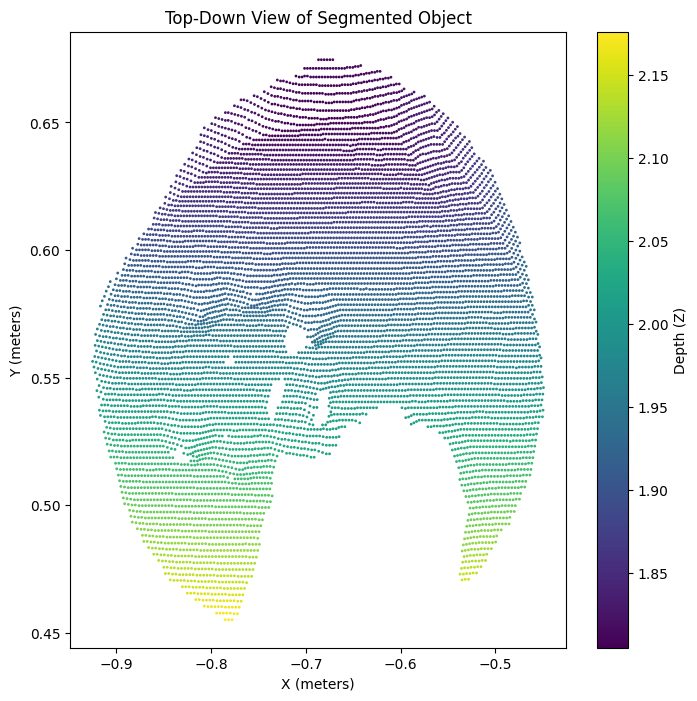

In [ ]:
# Plot the point cloud in 2D for a quick sanity check
points = np.asarray(object_pcd.points)
plt.figure(figsize=(8, 8))
# Plot X and Y (Top down view if Z is depth)
plt.scatter(points[:, 0], points[:, 1], s=1, c=points[:, 2], cmap='viridis')
plt.colorbar(label="Depth (Z)")
plt.title("Top-Down View of Segmented Object")
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.show()